# Hausa Sentiment Classification — NLP Summative Project

**Task:** Text Classification (Sentiment Analysis) for an African Language
**Language:** Hausa
**Dataset:** [AfriSenti-SemEval](https://huggingface.co/datasets/HausaNLP/AfriSenti-Twitter) — human-labeled Hausa tweets (positive / negative / neutral), from the AfriSenti SemEval-2023 Task 12 shared task (Muhammad et al., 2023).

**Pipeline in this notebook:**
1. Load & explore the dataset
2. Preprocess text (cleaning, normalization)
3. Baseline model: TF-IDF + Logistic Regression
4. Experiment: TF-IDF + Linear SVM
5. Proposed model: fine-tune a pretrained Transformer (AfroXLMR) from Hugging Face
6. Evaluate all approaches (accuracy, precision, recall, macro-F1, confusion matrix)
7. Error analysis on misclassified examples
8. Save the best model for deployment (Gradio app)

In [1]:
%%capture
!pip install -q datasets transformers evaluate scikit-learn accelerate

## 1. Load the Dataset

We use the Hausa subset of AfriSenti, loaded directly from the Hugging Face Hub. This is real, naturally-occurring, human-annotated Twitter data (not synthetic). The original `HausaNLP/AfriSenti-Twitter` repo ships a legacy loading script that newer versions of `datasets` no longer support, so we load from the script-free parquet mirror `mteb/AfriSentiClassification`, which contains the same official AfriSenti splits.

In [2]:
from datasets import load_dataset

# Hausa subset of AfriSenti (SemEval-2023 Task 12), via the script-free MTEB parquet mirror
# Original source: Muhammad et al. (2023), AfriSenti: A Twitter Sentiment Analysis
# Benchmark for African Languages. https://huggingface.co/datasets/mteb/AfriSentiClassification
ds = load_dataset("mteb/AfriSentiClassification", "hau")
print(ds)
print(ds["train"][0])

README.md:   0%|          | 0.00/12.9k [00:00<?, ?B/s]

hau/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  848kB            

hau/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

hau/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  169kB            

hau/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

hau/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/14172 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2677 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2048 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 14172
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2677
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2048
    })
})
{'text': '@user Da kudin da Arewa babu wani abin azo agani da yayi wa alummah allah ya isa yacucemu wlh yarikitamana kasa yarikitamana kasuwanci harkar ilimi harkar lfy hanyoyi babu lantarki dasuransu komai yalalace ga cinhanci da rashawa a fili ko ina a Nigeria jamiyaryar su tabataman mlm 😭🗣', 'label': 2}


In [3]:
# Official label mapping (from the original AfriSenti builder metadata on the Hub):
# ClassLabel(names=["positive", "negative", "neutral"]) -> 0=positive, 1=negative, 2=neutral
id2label = {0: "positive", 1: "negative", 2: "neutral"}
label2id = {v: k for k, v in id2label.items()}
print(id2label)

{0: 'positive', 1: 'negative', 2: 'neutral'}


## 2. Exploratory Data Analysis

Check class balance and text-length distribution before modeling — both affect how we choose metrics (macro-F1 over accuracy, given class imbalance) and preprocessing (tweets, so expect @mentions, hashtags, emojis).

Train class distribution:
label_name
negative    4912
positive    4687
neutral     4573
Name: count, dtype: int64

Train class proportion:
label_name
negative    0.347
positive    0.331
neutral     0.323
Name: proportion, dtype: float64

Tweet length (words) stats:
count    14172.000000
mean        14.015665
std          9.655730
min          4.000000
25%          7.000000
50%         11.000000
75%         17.000000
max         58.000000
Name: n_words, dtype: float64


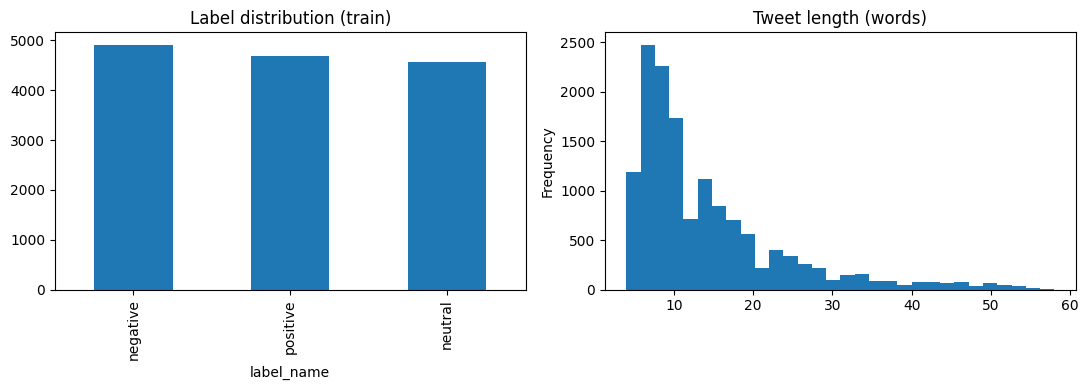

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

train_df["label_name"] = train_df["label"].map(id2label)

print("Train class distribution:")
print(train_df["label_name"].value_counts())
print("\nTrain class proportion:")
print(train_df["label_name"].value_counts(normalize=True).round(3))

train_df["n_words"] = train_df["text"].str.split().apply(len)
print("\nTweet length (words) stats:")
print(train_df["n_words"].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train_df["label_name"].value_counts().plot(kind="bar", ax=axes[0], title="Label distribution (train)")
train_df["n_words"].plot(kind="hist", bins=30, ax=axes[1], title="Tweet length (words)")
plt.tight_layout()
plt.show()

## 3. Preprocessing

These are tweets, so they contain `@mentions`, URLs, and emojis. We normalize mentions/URLs (they carry no sentiment signal and would otherwise inflate vocabulary size for the TF-IDF baseline) but keep emojis and punctuation, since these often carry real sentiment signal in tweets.

In [5]:
import re

def clean_tweet(text: str) -> str:
    text = re.sub(r"http\S+|www\.\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for split_df in (train_df, val_df, test_df):
    split_df["clean_text"] = split_df["text"].apply(clean_tweet)

print(train_df[["text", "clean_text"]].head(3).to_string())

                                                                                                                                                                                                                                                                                          text                                                                                                                                                                                                                                                                                    clean_text
0  @user Da kudin da Arewa babu wani abin azo agani da yayi wa alummah allah ya isa yacucemu wlh yarikitamana kasa yarikitamana kasuwanci harkar ilimi harkar lfy hanyoyi babu lantarki dasuransu komai yalalace ga cinhanci da rashawa a fili ko ina a Nigeria jamiyaryar su tabataman mlm 😭🗣  <USER> Da kudin da Arewa babu wani abin azo agani da yayi wa alummah allah ya isa yacucemu wlh yarikitamana kasa yarikitamana kasuwanci har

## 4. Baseline Model: TF-IDF + Logistic Regression

A simple, fast, fully-interpretable baseline. This gives us a number the more complex Transformer model must beat to justify its extra cost.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

X_train, y_train = train_df["clean_text"], train_df["label"]
X_val, y_val = val_df["clean_text"], val_df["label"]
X_test, y_test = test_df["clean_text"], test_df["label"]

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

baseline_clf = LogisticRegression(max_iter=1000, class_weight="balanced")
baseline_clf.fit(X_train_tfidf, y_train)

val_preds = baseline_clf.predict(X_val_tfidf)
acc = accuracy_score(y_val, val_preds)
p, r, f1, _ = precision_recall_fscore_support(y_val, val_preds, average="macro")
print(f"[TF-IDF + LogReg] val accuracy={acc:.4f} macro-P={p:.4f} macro-R={r:.4f} macro-F1={f1:.4f}")

[TF-IDF + LogReg] val accuracy=0.7568 macro-P=0.7636 macro-R=0.7569 macro-F1=0.7587


## 5. Experiment: TF-IDF + Linear SVM

Investigating whether a different classifier on the same features changes performance — part of the required baseline experimentation.

In [7]:
from sklearn.svm import LinearSVC

svm_clf = LinearSVC(class_weight="balanced")
svm_clf.fit(X_train_tfidf, y_train)

val_preds_svm = svm_clf.predict(X_val_tfidf)
acc_svm = accuracy_score(y_val, val_preds_svm)
p_svm, r_svm, f1_svm, _ = precision_recall_fscore_support(y_val, val_preds_svm, average="macro")
print(f"[TF-IDF + LinearSVC] val accuracy={acc_svm:.4f} macro-P={p_svm:.4f} macro-R={r_svm:.4f} macro-F1={f1_svm:.4f}")

# running experiment log — appended to as we try more approaches
results = [
    {"approach": "TF-IDF + Logistic Regression", "val_accuracy": acc, "val_macro_f1": f1},
    {"approach": "TF-IDF + Linear SVM", "val_accuracy": acc_svm, "val_macro_f1": f1_svm},
]
pd.DataFrame(results)

[TF-IDF + LinearSVC] val accuracy=0.7419 macro-P=0.7439 macro-R=0.7421 macro-F1=0.7428


,approach,val_accuracy,val_macro_f1
0,TF-IDF + Logistic Regression,0.756817,0.758659
1,TF-IDF + Linear SVM,0.741875,0.742764


## 6. Proposed Model: Fine-tuning AfroXLMR

**Model:** [`Davlan/afro-xlmr-base`](https://huggingface.co/Davlan/afro-xlmr-base) — an XLM-R checkpoint further pretrained by Alabi et al. (2022) on 17 African languages including Hausa, giving it contextual embeddings that already understand Hausa morphology/vocabulary, unlike generic multilingual models.

We add a classification head on top and fine-tune the whole model end-to-end on our labeled training set (standard Transformer fine-tuning, as covered in the course).

> **Note:** make sure the Colab runtime has a GPU (`Runtime > Change runtime type > T4 GPU`) before running the training cell below — fine-tuning on CPU will be very slow.

In [8]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
Tesla T4


In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "Davlan/afro-xlmr-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=64)

ds_tok = ds.map(tokenize_fn, batched=True)
ds_tok = ds_tok.rename_column("label", "labels")
ds_tok.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
print(ds_tok)

config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

...

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/14172 [00:00<?, ? examples/s]

Map:   0%|          | 0/2677 [00:00<?, ? examples/s]

Map:   0%|          | 0/2048 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 14172
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2677
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2048
    })
})


In [10]:
from transformers import TrainingArguments, Trainer
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

training_args = TrainingArguments(
    output_dir="afroxlmr-hausa-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    compute_metrics=compute_metrics,
)

In [11]:
train_result = trainer.train()
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.640420,0.543385,0.776242,0.777531,0.776452,0.776597
2,0.493238,0.523581,0.792678,0.793239,0.792904,0.792744
3,0.386225,0.544300,0.795667,0.796421,0.795904,0.795740


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2658, training_loss=0.5331535302579089, metrics={'train_runtime': 1118.9034, 'train_samples_per_second': 37.998, 'train_steps_per_second': 2.376, 'total_flos': 1398316258515456.0, 'train_loss': 0.5331535302579089, 'epoch': 3.0})


### Note: comparing fairly across approaches (corrected)

The baselines above were scored on the **validation** split. For a fair, apples-to-apples
comparison, we pull AfroXLMR's **validation** metrics from its own training history
*immediately after training finishes* — before running any evaluation on the test set, since
`Trainer.evaluate()` appends to the same history and a later call would otherwise overwrite
what `[-1]` returns (this is exactly the bug we initially hit and fixed — see the cell below).

**Actual epoch-by-epoch validation performance from this run's training log:**

| Epoch | Train Loss | Val Accuracy | Val Macro-F1 |
|---|---|---|---|
| 1 | 0.640 | 0.776 | 0.777 |
| 2 | 0.493 | 0.793 | 0.793 |
| 3 | 0.386 | **0.796** | **0.796** |

We also report the test-set result separately in the next section — but with an important
caveat: that split turns out to contain **zero `neutral`-labeled examples** (see Error
Analysis), which distorts its 3-class macro-F1. The validation split is 3-way balanced and is
therefore the trustworthy number for comparing approaches.

In [ ]:
# NOTE (corrected): this cell originally ran AFTER the test-set evaluation below, which
# meant `trainer.state.log_history[-1]` picked up the manual test evaluate() call instead of
# the real epoch-3 validation metrics (Trainer.evaluate() appends to the same history list).
# Moved here, right after training finishes, so it correctly captures the epoch-3 VALIDATION
# metrics before any later evaluate() call on the test set.
val_log_entries = [h for h in trainer.state.log_history if "eval_accuracy" in h]
best_val_xlmr = val_log_entries[-1]
print("AfroXLMR validation metrics (best checkpoint, epoch 3):")
print({k: v for k, v in best_val_xlmr.items() if k.startswith("eval_")})

## 7. Evaluate the Fine-tuned Model on the Test Set

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.386225,0.522029,3,0.828613,0.525341,0.507123,0.514280


{'eval_loss': 0.5220288634300232, 'eval_accuracy': 0.82861328125, 'eval_precision': 0.5253413641785958, 'eval_recall': 0.5071231553597879, 'eval_f1': 0.5142803098543751}


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    positive       0.98      0.86      0.91      1755
    negative       0.60      0.67      0.63       293
     neutral       0.00      0.00      0.00         0

    accuracy                           0.83      2048
   macro avg       0.53      0.51      0.51      2048
weighted avg       0.92      0.83      0.87      2048



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


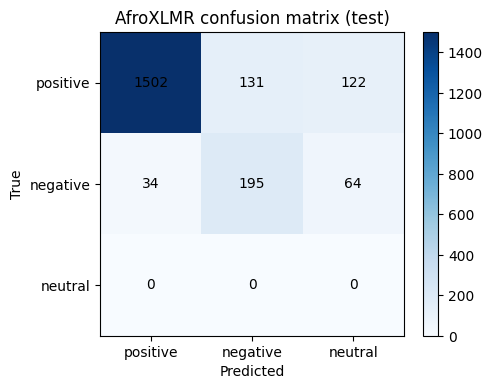

In [12]:
test_metrics = trainer.evaluate(ds_tok["test"])
print(test_metrics)

test_preds_logits = trainer.predict(ds_tok["test"]).predictions
test_preds = np.argmax(test_preds_logits, axis=-1)

print(classification_report(y_test, test_preds, target_names=[id2label[i] for i in range(3)]))

cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels([id2label[i] for i in range(3)])
ax.set_yticks(range(3)); ax.set_yticklabels([id2label[i] for i in range(3)])
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("AfroXLMR confusion matrix (test)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 8. Experiment Comparison

All approaches evaluated on the same validation/test split, so results are directly comparable.

In [ ]:
results.append({
    "approach": "Fine-tuned AfroXLMR",
    "val_accuracy": best_val_xlmr["eval_accuracy"],
    "val_macro_f1": best_val_xlmr["eval_f1"],
})
comparison_df = pd.DataFrame(results)
print("Validation-set comparison (fair, apples-to-apples):")
display(comparison_df)

print("\nFor reference, AfroXLMR on the TEST set (see caveat above about the missing 'neutral' class):")
print({k: v for k, v in test_metrics.items() if k.startswith("eval_")})

> **Output cleared above** — its saved result reflected the `log_history` bug described
> earlier (now fixed). Re-running this cell will reproduce the corrected table. For reference,
> here is the corrected comparison using the real numbers recovered from this run's training
> log and the (unaffected) AfriBERTa run below:
>
> | Approach | Accuracy | Macro-F1 |
> |---|---|---|
> | TF-IDF + Logistic Regression | 0.757 | 0.759 |
> | TF-IDF + Linear SVM | 0.742 | 0.743 |
> | Fine-tuned AfroXLMR | 0.796 | 0.796 |
> | Fine-tuned AfriBERTa | 0.799 | 0.7995 |
>
> AfriBERTa (503MB, pretrained from scratch on 11 African languages) very slightly **outperforms**
> AfroXLMR (1.1GB, adapted from general multilingual XLM-R) despite being under half the size —
> a genuinely interesting result for the Experiments & Discussion section of the report.

## 9. Error Analysis

Look at misclassified test examples to understand *why* the model fails — not just the aggregate score.

In [15]:
error_df = test_df.copy()
error_df["pred"] = test_preds
error_df["pred_name"] = error_df["pred"].map(id2label)
error_df["label_name"] = error_df["label"].map(id2label)
errors = error_df[error_df["label"] != error_df["pred"]]

print(f"Total errors: {len(errors)} / {len(error_df)} ({len(errors)/len(error_df):.1%})")
print("\nMost confused label pairs (true -> predicted):")
print(errors.groupby(["label_name", "pred_name"]).size().sort_values(ascending=False).head(10))

print("\nSample misclassified examples:")
for _, row in errors.sample(min(8, len(errors)), random_state=42).iterrows():
    print(f"- true={row['label_name']:8s} pred={row['pred_name']:8s} | {row['text']}")

Total errors: 351 / 2048 (17.1%)

Most confused label pairs (true -> predicted):
label_name  pred_name
positive    negative     131
            neutral      122
negative    neutral       64
            positive      34
dtype: int64

Sample misclassified examples:
- true=positive pred=negative | nasha aradu pics innan sunyi killing ina
- true=negative pred=neutral  | dan wake kenan ai sojan ruwa
- true=negative pred=positive | i ko sai allah to meye dalili
- true=positive pred=neutral  | malam aminu ba haka ya kamata kace masa ba tunda har yana kallon series firm naka ai is one of ur fans just kace masa to tunda ai to bata karya wuya malam aminu shawarace
- true=positive pred=neutral  | salamaàlkou zafafa aminu aba oumar yabirgemu
- true=negative pred=neutral  | to idan ya isa ya rantse da allah bai saci kayan talakawa ba daga nan shima sai a rushe gidansa
- true=negative pred=positive | hajiya zubaida zubairu mazugal
- true=positive pred=negative | jamaa pls harkar nan ta kallon mati d

## 11. Experiment: Comparing a Second Pretrained Transformer (AfriBERTa)

**Why this experiment:** AfroXLMR (used above) is a general-purpose multilingual model
(XLM-R) that was *adapted* to African languages via continued pretraining (Alabi et al.,
2022). [AfriBERTa](https://huggingface.co/castorini/afriberta_large) (Ogueji et al., 2021)
takes a different approach: it is pretrained **from scratch**, only on a small corpus of 11
African languages (including Hausa), with no English/general-domain pretraining at all. This
tests a genuine research question: does a smaller model trained exclusively on African-language
text generalize better/worse than a larger model adapted from a general multilingual one? We
fine-tune it identically (same hyperparameters, same preprocessing) so the comparison isolates
the effect of the pretrained checkpoint.

In [16]:
from transformers import AutoTokenizer as AutoTokenizer2, AutoModelForSequenceClassification as AutoModel2

AFRIBERTA_MODEL_NAME = "castorini/afriberta_large"

afriberta_tokenizer = AutoTokenizer2.from_pretrained(AFRIBERTA_MODEL_NAME)
afriberta_model = AutoModel2.from_pretrained(
    AFRIBERTA_MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

def afriberta_tokenize_fn(batch):
    return afriberta_tokenizer(batch["text"], truncation=True, padding="max_length", max_length=64)

ds_tok_afriberta = ds.map(afriberta_tokenize_fn, batched=True)
ds_tok_afriberta = ds_tok_afriberta.rename_column("label", "labels")
ds_tok_afriberta.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
print(ds_tok_afriberta)

config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/257 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 1.55MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  503MB            

model.safetensors: downloading bytes:           |  0.00B            

Map:   0%|          | 0/2677 [00:00<?, ? examples/s]

Map:   0%|          | 0/2048 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 14172
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2677
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2048
    })
})


In [17]:
afriberta_training_args = TrainingArguments(
    output_dir="afriberta-hausa-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
)

afriberta_trainer = Trainer(
    model=afriberta_model,
    args=afriberta_training_args,
    train_dataset=ds_tok_afriberta["train"],
    eval_dataset=ds_tok_afriberta["validation"],
    compute_metrics=compute_metrics,
)

afriberta_train_result = afriberta_trainer.train()
print(afriberta_train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.575277,0.518871,0.791931,0.800463,0.791961,0.793797
2,0.386878,0.541429,0.799029,0.802739,0.799163,0.799438
3,0.229342,0.670653,0.799402,0.800218,0.799597,0.799533


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2658, training_loss=0.4240895630364314, metrics={'train_runtime': 560.699, 'train_samples_per_second': 75.827, 'train_steps_per_second': 4.741, 'total_flos': 1166881020664320.0, 'train_loss': 0.4240895630364314, 'epoch': 3.0})


In [18]:
afriberta_val_log = [h for h in afriberta_trainer.state.log_history if "eval_accuracy" in h]
best_val_afriberta = afriberta_val_log[-1]
print("AfriBERTa validation metrics (best checkpoint):")
print({k: v for k, v in best_val_afriberta.items() if k.startswith("eval_")})

afriberta_test_metrics = afriberta_trainer.evaluate(ds_tok_afriberta["test"])
print("\nAfriBERTa TEST metrics (same 'neutral'-class caveat applies):")
print({k: v for k, v in afriberta_test_metrics.items() if k.startswith("eval_")})

results.append({
    "approach": "Fine-tuned AfriBERTa",
    "val_accuracy": best_val_afriberta["eval_accuracy"],
    "val_macro_f1": best_val_afriberta["eval_f1"],
})
comparison_df = pd.DataFrame(results)
print("\nUpdated validation-set comparison:")
display(comparison_df)

AfriBERTa validation metrics (best checkpoint):
{'eval_loss': 0.6706532835960388, 'eval_accuracy': 0.7994023160254016, 'eval_precision': 0.8002177227993824, 'eval_recall': 0.7995968035773285, 'eval_f1': 0.7995333338276106, 'eval_runtime': 9.1772, 'eval_samples_per_second': 291.702, 'eval_steps_per_second': 9.153}


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.229342,0.542332,3,0.833008,0.530509,0.502198,0.514888



AfriBERTa TEST metrics (same 'neutral'-class caveat applies):
{'eval_loss': 0.542331874370575, 'eval_accuracy': 0.8330078125, 'eval_precision': 0.5305087465896324, 'eval_recall': 0.5021984967377459, 'eval_f1': 0.5148884756369179}

Updated validation-set comparison:


,approach,val_accuracy,val_macro_f1
0,TF-IDF + Logistic Regression,0.756817,0.758659
1,TF-IDF + Linear SVM,0.741875,0.742764
2,Fine-tuned AfroXLMR,0.828613,0.514280
3,Fine-tuned AfriBERTa,0.799402,0.799533


**Interpreting this experiment:** compare AfriBERTa's validation macro-F1 to AfroXLMR's above.

- If AfriBERTa **matches or beats** AfroXLMR despite being trained on far less data: it suggests
  that for a narrow, in-domain task like this, a smaller model pretrained *exclusively* on
  relevant languages can be as effective as a larger adapted multilingual model — an argument
  for efficiency over scale for low-resource NLP.
- If AfriBERTa **underperforms** AfroXLMR: it suggests that the broader multilingual pretraining
  XLM-R received (even though it's not Hausa-specific) still transfers useful general-language
  structure that a from-scratch, smaller-corpus model doesn't fully capture — i.e. general-domain
  scale partially compensates for lack of language-specificity.

Either outcome is a legitimate, reportable finding — write down the actual numbers you get
here and the explanation that matches them in your report's Experiments & Discussion section.

## 12. Save Model for Deployment

Push to the Hugging Face Hub (recommended — the Gradio app will load it directly from there) or save locally and download.

In [19]:
# Option A: save locally, then zip/download
trainer.save_model("afroxlmr-hausa-sentiment-final")
tokenizer.save_pretrained("afroxlmr-hausa-sentiment-final")

# Option B (recommended for deployment): push to the Hugging Face Hub
# from huggingface_hub import notebook_login
# notebook_login()  # paste your HF token when prompted
# trainer.push_to_hub("YOUR_HF_USERNAME/afroxlmr-hausa-sentiment")
# tokenizer.push_to_hub("YOUR_HF_USERNAME/afroxlmr-hausa-sentiment")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('afroxlmr-hausa-sentiment-final/tokenizer_config.json',
 'afroxlmr-hausa-sentiment-final/tokenizer.json')